## Import Libraries

In [301]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import confusion_matrix, roc_auc_score

## Load Dataset

In [302]:
df = pd.read_excel("LogData.xlsx")
df.head()

,x,TT
0,84.898,0
1,47.335,1
2,21.867,0
3,138.166,1
4,113.358,1


## Question 1.1

In [303]:
X = df[["x"]]
y = df["TT"]

# Add intercept
X_const = sm.add_constant(X)

In [304]:
# Fit logistic regression model
model_simple = sm.Logit(y, X_const)
results_simple = model_simple.fit()

Optimization terminated successfully.
         Current function value: 0.619700
         Iterations 5


In [305]:
# Print summary
print(results_simple.summary())

                           Logit Regression Results                           
Dep. Variable:                     TT   No. Observations:                  500
Model:                          Logit   Df Residuals:                      498
Method:                           MLE   Df Model:                            1
Date:                Thu, 11 Jun 2026   Pseudo R-squ.:                  0.1055
Time:                        19:44:50   Log-Likelihood:                -309.85
converged:                       True   LL-Null:                       -346.38
Covariance Type:            nonrobust   LLR p-value:                 1.261e-17
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.9496      0.270     -7.218      0.000      -2.479      -1.420
x              0.0243      0.003      7.951      0.000       0.018       0.030


In [306]:
# Get coefficient values
beta0 =results_simple.params["const"]
beta1 =results_simple.params["x"]

print("beta0:", beta0)
print("beta1:", beta1)

beta0: -1.9496450602371016
beta1: 0.02429132244443248


In [307]:
# Predicted probabilities
df["p_hat_simple"] = results_simple.predict(X_const)

# Predicted classes using threshold 0.5
df["TT_pred_simple"] = (df["p_hat_simple"] >= 0.5).astype(int)

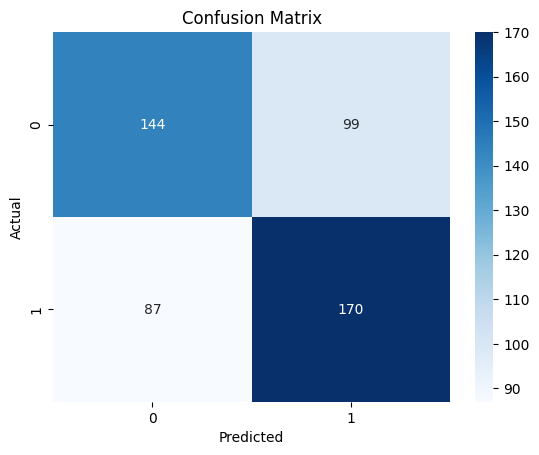

In [308]:
# Confusion matrix
cm_simple = confusion_matrix(y, df["TT_pred_simple"])

sns.heatmap(cm_simple, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title("Confusion Matrix")
plt.show()

In [309]:
# AUC and Somers' D
auc_simple = roc_auc_score(y, df["p_hat_simple"])
somers_d_simple = 2 * auc_simple - 1

print("AUC:", auc_simple)
print("Somers' D:", somers_d_simple)

AUC: 0.722662567452883
Somers' D: 0.4453251349057661


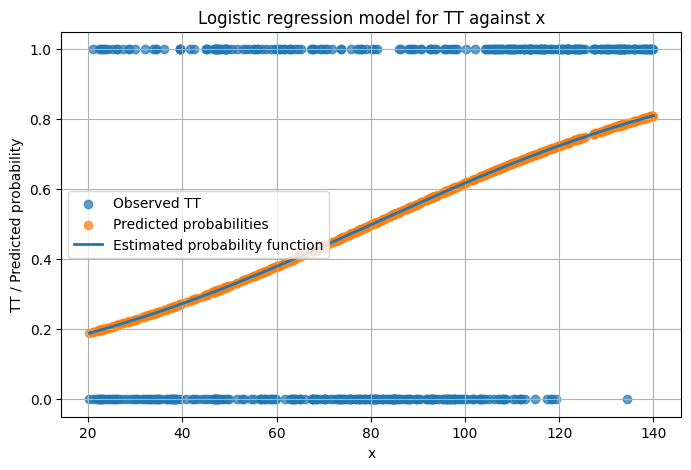

In [319]:
# Scatter Plot
x_grid = np.linspace(df["x"].min(), df["x"].max(), 300)
x_grid_simple = pd.DataFrame({"x": x_grid})
X_grid_const_simple = sm.add_constant(x_grid_simple)
p_grid_simple = results_simple.predict(X_grid_const_simple)

plt.figure(figsize=(8, 5))

plt.scatter(df["x"], df["TT"], label="Observed TT", alpha=0.7)
plt.scatter(df["x"], df["p_hat_simple"], label="Predicted probabilities", alpha=0.7)
plt.plot(x_grid, p_grid_simple, label="Estimated probability function", linewidth=2)

plt.xlabel("x")
plt.ylabel("TT / Predicted probability")
plt.title("Logistic regression model for TT against x")
plt.legend()
plt.grid(True)
plt.show()

## Question 1.2

In [311]:
x = df["x"]
y = df["TT"]

# Define truncated power function
def truncated_power(x, knot):
    return np.maximum(x - knot, 0)**3

# Construct cubic spline basis functions
X_spline = pd.DataFrame({
    "x": x,
    "x2": x**2,
    "x3": x**3,
    "x_minus_50_cubed_plus": truncated_power(x, 50),
    "x_minus_80_cubed_plus": truncated_power(x, 80)
})

# Add intercept
X_spline_const = sm.add_constant(X_spline)

In [312]:
# Fit spline logistic regression model
model_spline = sm.Logit(y, X_spline_const)
results_spline = model_spline.fit()

Optimization terminated successfully.
         Current function value: 0.521766
         Iterations 8


In [313]:
# Print summary
print(results_spline.summary())

                           Logit Regression Results                           
Dep. Variable:                     TT   No. Observations:                  500
Model:                          Logit   Df Residuals:                      494
Method:                           MLE   Df Model:                            5
Date:                Thu, 11 Jun 2026   Pseudo R-squ.:                  0.2468
Time:                        19:44:50   Log-Likelihood:                -260.88
converged:                       True   LL-Null:                       -346.38
Covariance Type:            nonrobust   LLR p-value:                 4.487e-35
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    11.5914      6.027      1.923      0.054      -0.222      23.405
x                        -1.0457      0.459     -2.278      0.023      -1.945      -0.146
x2      

In [314]:
# Predicted probabilities
df["p_hat_spline"] = results_spline.predict(X_spline_const)

# Predicted classes using threshold 0.5
df["TT_pred_spline"] = (df["p_hat_spline"] >= 0.5).astype(int)

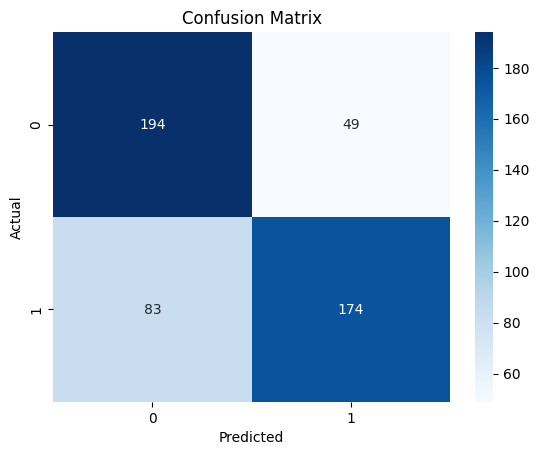

In [315]:
# Confusion matrix
cm_spline = confusion_matrix(y, df["TT_pred_spline"])

sns.heatmap(cm_spline, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title("Confusion Matrix")
plt.show()

In [316]:
# AUC and Somers' D
auc_spline = roc_auc_score(y, df["p_hat_spline"])
somers_d_spline = 2 * auc_spline - 1

print("AUC:", auc_spline)
print("Somers' D:", somers_d_spline)

AUC: 0.800787817649037
Somers' D: 0.6015756352980739


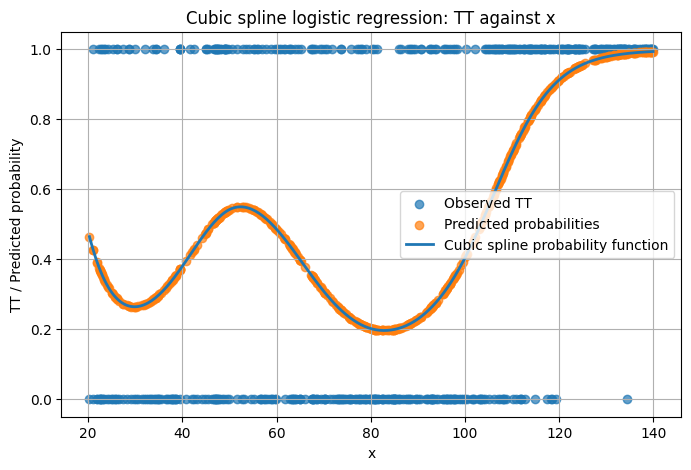

In [318]:
# Scatter Plot
X_grid = np.linspace(df["x"].min(), df["x"].max(), 300)

X_grid_spline = pd.DataFrame({
    "x": X_grid,
    "x2": X_grid**2,
    "x3": X_grid**3,
    "x_minus_50_cubed_plus": truncated_power(X_grid, 50),
    "x_minus_80_cubed_plus": truncated_power(X_grid, 80)
})
X_grid_spline_const = sm.add_constant(X_grid_spline)
p_grid_spline = results_spline.predict(X_grid_spline_const)

plt.figure(figsize=(8, 5))

plt.scatter(df["x"], df["TT"], label="Observed TT", alpha=0.7)
plt.scatter(df["x"], df["p_hat_spline"], label="Predicted probabilities", alpha=0.7)
plt.plot(X_grid, p_grid_spline, label="Cubic spline probability function", linewidth=2)

plt.xlabel("x")
plt.ylabel("TT / Predicted probability")
plt.title("Cubic spline logistic regression: TT against x")
plt.legend()
plt.grid(True)
plt.show()